In [1]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [2]:
BATCH_SIZE = 8
EPOCHS = 5
NUM_CLASSES = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True

In [3]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(3),  # convert 1-channel → 3-channel
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor(),
])

In [4]:
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=train_tf
)

val_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=val_tf
)

train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(val_ds,batch_size=BATCH_SIZE)

print("Train samples:", len(train_ds))
print("Validation samples:", len(val_ds))

100%|██████████| 26.4M/26.4M [00:06<00:00, 4.28MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 29.4MB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Train samples: 60000
Validation samples: 10000


In [5]:
def load_model():

    model = models.googlenet(
        weights=models.GoogLeNet_Weights.DEFAULT
    )

    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    return model.to(device)

model = load_model()

print("Device:", device)
writer = SummaryWriter("runs/fashion_googlenet")

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to C:\Users\nisan/.cache\torch\hub\checkpoints\googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:01<00:00, 26.3MB/s]


Device: cuda


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [7]:
def evaluate():

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for imgs,labels in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            preds = outputs.argmax(1)

            correct += (preds==labels).sum().item()
            total += labels.size(0)

    return correct/total

In [8]:
def train():
    train_losses = []
    val_accs = []

    for epoch in range(EPOCHS):

        model.train()

        running_loss = 0
        t0 = time.time()

        for imgs,labels in train_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(imgs)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss)

        val_acc = evaluate()

        val_accs.append(val_acc)

        writer.add_scalar("Loss/train", running_loss, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

        elapsed = time.time() - t0

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"loss={running_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"time={elapsed:.1f}s"
        )

    print("Training finished.")
    
    return train_losses, val_accs

Epoch 1/5 | loss=2499.9432 | val_acc=0.9280 | time=308.9s
Epoch 2/5 | loss=1551.3740 | val_acc=0.9305 | time=325.7s
Epoch 3/5 | loss=1315.4482 | val_acc=0.9322 | time=444.7s
Epoch 4/5 | loss=1124.8802 | val_acc=0.9423 | time=493.2s
Epoch 5/5 | loss=1004.8332 | val_acc=0.9457 | time=508.2s
Training finished.


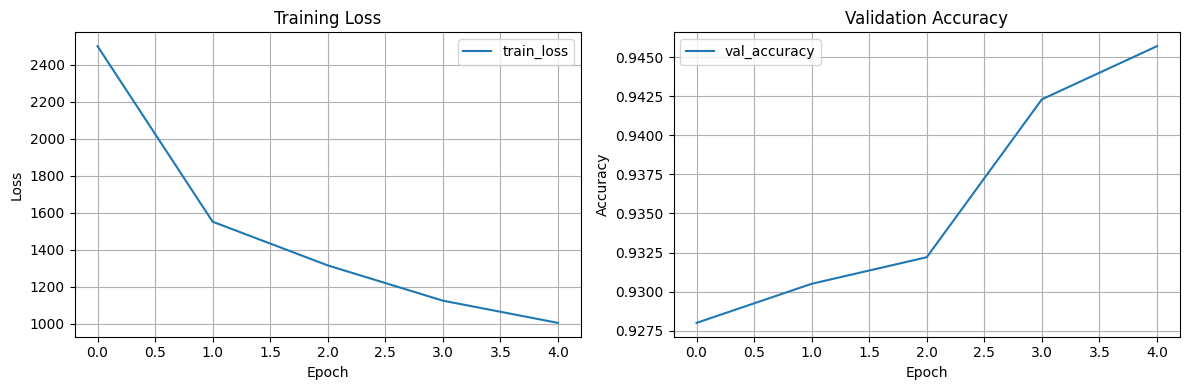

In [9]:
if __name__ == "__main__":
    train_losses, val_accs = train()
    writer.close()
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(train_losses, label="train_loss")
    ax1.set_title("Training Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(val_accs, label="val_accuracy")
    ax2.set_title("Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()